In [59]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent
data_path = project_root /"data" / "raw" / "complaints_processed.csv"

df = pd.read_csv(data_path)
df.head()


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [60]:
print(df.shape)
print(df.info())
df = df.dropna(subset=["narrative"])

(162421, 3)
<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  162421 non-null  int64
 1   product     162421 non-null  str  
 2   narrative   162411 non-null  str  
dtypes: int64(1), str(2)
memory usage: 97.3 MB
None


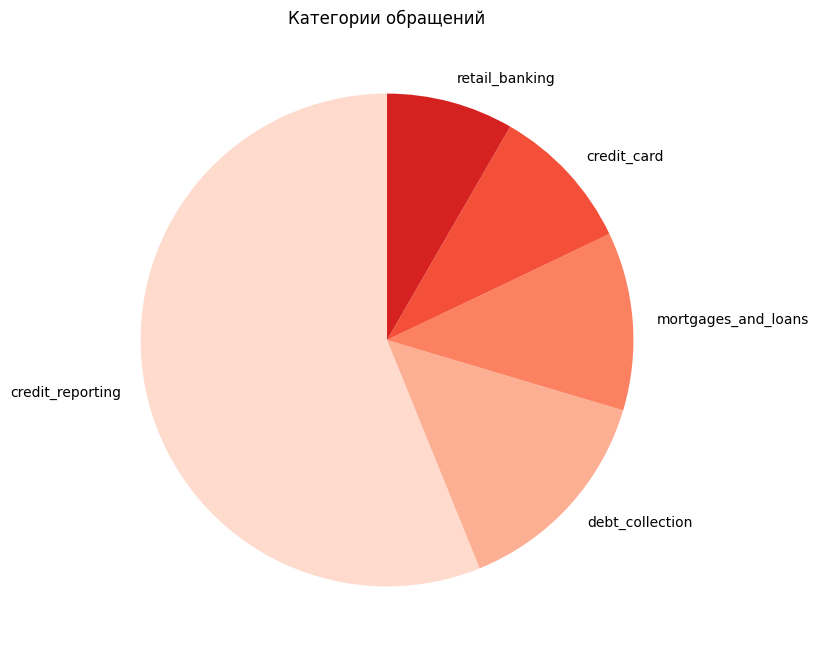

In [61]:
counts = df["product"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels = counts.index,
    colors=sns.color_palette("Reds"),
    startangle=90
)
plt.title("Категории обращений")
plt.show()

классы разбалансированны

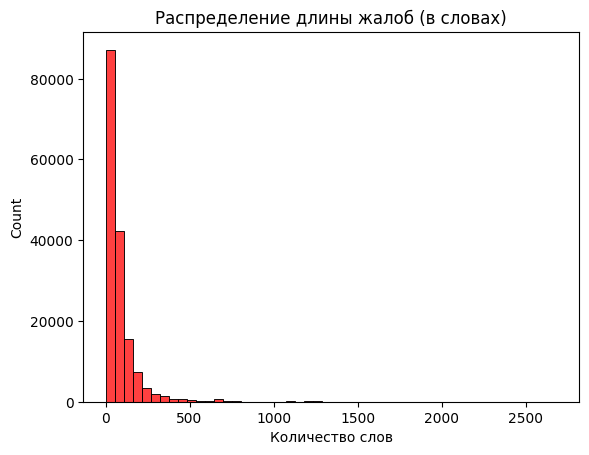

In [62]:
df["narrative_length"] = df["narrative"].str.split().str.len()
sns.histplot(df["narrative_length"], bins=50, color="Red")
plt.title("Распределение длины жалоб (в словах)")
plt.xlabel("Количество слов")
plt.show()

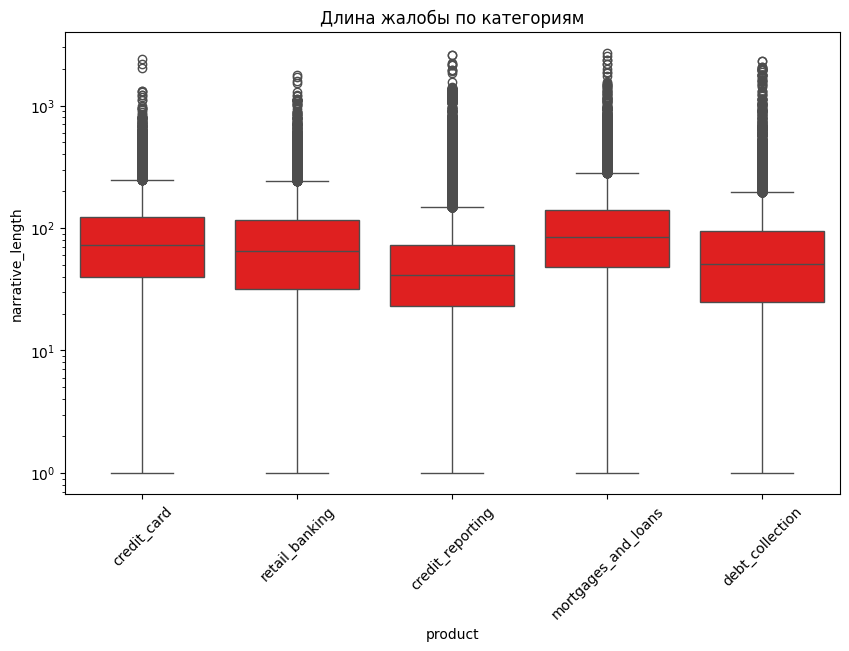

                       count        mean         std  min   25%   50%    75%  \
product                                                                        
credit_card          15566.0   98.166517   99.374742  1.0  40.0  72.0  123.0   
credit_reporting     91172.0   67.794103  103.210738  1.0  23.0  41.0   73.0   
debt_collection      23148.0   78.764472  110.476726  1.0  25.0  51.0   94.0   
mortgages_and_loans  18990.0  117.497420  129.441452  1.0  48.0  84.0  141.0   
retail_banking       13535.0   93.623125  105.813348  1.0  32.0  65.0  116.0   

                        max  
product                      
credit_card          2412.0  
credit_reporting     2568.0  
debt_collection      2325.0  
mortgages_and_loans  2685.0  
retail_banking       1777.0  


In [63]:
products = df.groupby("product")["narrative_length"].describe()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="product", y="narrative_length", color="Red")
plt.yscale("log")
plt.title("Длина жалобы по категориям")
plt.xticks(rotation=45)
plt.show()
print(products)

In [64]:
for product in df["product"].unique():
    print(product)
    print(df[df["product"]==product]["narrative"].sample(2, random_state=42).values)
    print()

credit_card
<ArrowStringArray>
['saturday make sevice appointment mother give credit card number company told time may allowed facility covid charge showed immediately pending surprise said would charged canceled immediately found would allowed canceled service call tentatively scheduled one week later saturday canceled email phone chat confirmed would charged charge went pending charge day canceling wednesday upon calling service company part citi visa informed would receive credit day disputing credit take long pay credit card full every month close next couple day pay interest charge allowed hit immediately undisputed credit allowed take day criminal scam service provider credit card company much legality delay', 'early opened dispute transaction citibank credit card dispute amount payment transporting automobile california iowa ultimately merchant never provided auto transport service citibank yet resolved dispute received phone call automobile transport company merchant merchant g

Очистка

In [65]:
def remove_mask(text):
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["narrative_clean"] = df["narrative"].apply(remove_mask)

In [66]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [67]:
df = df.drop_duplicates(subset="narrative", keep="first")

In [ ]:
from tqdm import tqdm
texts = df["narrative_clean"].tolist()

lemmatized = []
for doc in tqdm(nlp.pipe(texts, batch_size=100), total=len(texts)):
    lemmatized.append(" ".join(token.lemma_ for token in doc))

df["narrative_clean"] = lemmatized
df["narrative_clean"].head()

In [69]:

X_train, X_test, y_train, y_test = train_test_split(
    df["narrative_clean"],
    df["product"],
    test_size=0.2,
    random_state= 42,
    stratify = df["product"]
)
print(y_train.value_counts(normalize=True))
y_test.value_counts(normalize=True)

product
credit_reporting       0.451831
debt_collection        0.169176
mortgages_and_loans    0.150416
credit_card            0.120369
retail_banking         0.108208
Name: proportion, dtype: float64


product
credit_reporting       0.451818
debt_collection        0.169150
mortgages_and_loans    0.150432
credit_card            0.120386
retail_banking         0.108215
Name: proportion, dtype: float64

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, min_df=5)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
vectorizer.get_feature_names_out()[:20]

(99577, 5000)
(24895, 5000)


array(['aa', 'aadvantage', 'aag', 'aargon', 'ab', 'abandon', 'abide',
       'ability', 'able', 'abroad', 'abruptly', 'absence', 'absent',
       'absolute', 'absolutely', 'absolve', 'absurd', 'abundance',
       'abuse', 'abusive'], dtype=object)

In [78]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)


In [80]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8509

                     precision    recall  f1-score   support

        credit_card       0.80      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.88     11248
    debt_collection       0.81      0.74      0.77      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.87      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.83      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



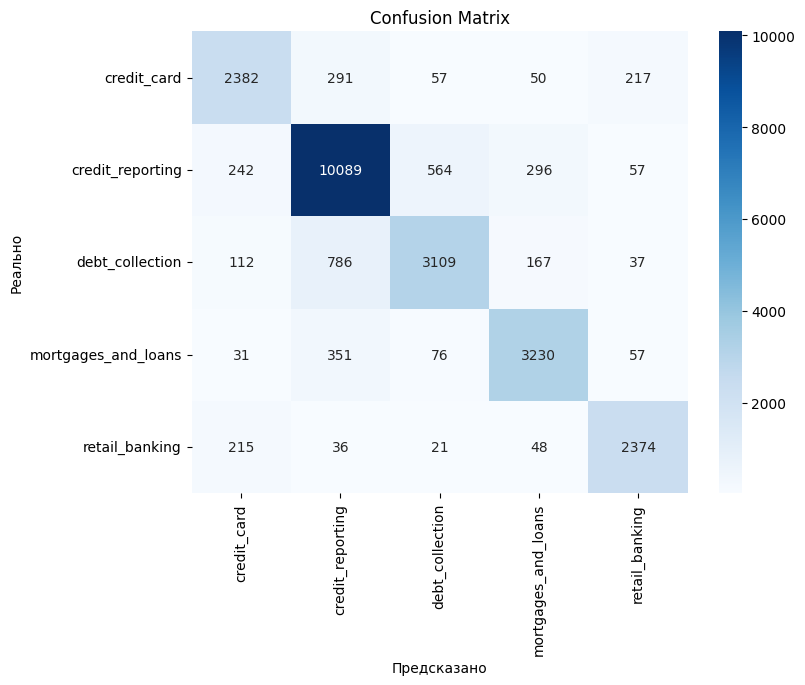

In [81]:
from sklearn.metrics import confusion_matrix


labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Confusion Matrix")
plt.show()

In [83]:
errors = X_test[y_test != y_pred]
error_true = y_test[y_test != y_pred]
error_pred = y_pred[y_test != y_pred]

for text, true_label, pred_label in list(zip(errors, error_true, error_pred))[:10]:
    print(f"РЕАЛЬНО: {true_label} | ПРЕДСКАЗАНО: {pred_label}")
    print(text[:200])
    print()

РЕАЛЬНО: mortgages_and_loans | ПРЕДСКАЗАНО: credit_reporting
original loan company buy buy onemain financial date original loan amount account number onemain report negative information credit report account charge account pay agree also pay full receive certif

РЕАЛЬНО: debt_collection | ПРЕДСКАЗАНО: credit_reporting
equifax show collection credit report client account go delinquency point within statute limitation fair credit reporting act receive communication year contact equifax recently claim verify debt mine

РЕАЛЬНО: credit_reporting | ПРЕДСКАЗАНО: debt_collection
enhance recovery report debt credit file owe recently check credit file notice debt call immediately pay debt never receive phone call collection notice letter pretty sure violate day right dispute

РЕАЛЬНО: credit_reporting | ПРЕДСКАЗАНО: debt_collection
year yell company credit card steal send account atty speak supposedly attorney state never get notice affidavit fill send police info give account hurt score tell p

у пары debt_collection/credit_reporting есть content overlap - это ограничение датасета/предметной области, а не просто "модель недоучилась". Полностью убрать эту ошибку вряд ли получится улучшением модели - можно только снизить её.

In [86]:
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train_tfidf, y_train)
y_pred = model_balanced.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))


                     precision    recall  f1-score   support

        credit_card       0.73      0.84      0.78      2997
   credit_reporting       0.93      0.80      0.86     11248
    debt_collection       0.74      0.81      0.78      4211
mortgages_and_loans       0.79      0.89      0.84      3745
     retail_banking       0.83      0.90      0.86      2694

           accuracy                           0.83     24895
          macro avg       0.80      0.85      0.82     24895
       weighted avg       0.84      0.83      0.83     24895



общий F1 не улучшился

In [91]:
vectorizer_bigram = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    min_df = 5
    )

X_train_bigram = vectorizer_bigram.fit_transform(X_train)
X_test_bigram = vectorizer_bigram.transform(X_test)

model_bigram = LogisticRegression(max_iter=1000)
model_bigram.fit(X_train_bigram, y_train)
y_pred_bigram = model_bigram.predict(X_test_bigram)

print(classification_report(y_test, y_pred_bigram))

0it [1:01:26, ?it/s]


                     precision    recall  f1-score   support

        credit_card       0.81      0.79      0.80      2997
   credit_reporting       0.87      0.90      0.89     11248
    debt_collection       0.81      0.74      0.77      4211
mortgages_and_loans       0.85      0.86      0.86      3745
     retail_banking       0.87      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.84      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



не дало результата вероятно из-за того, что словарь забит одиночными словами


In [92]:
from sklearn.svm import LinearSVC

model_svc = LinearSVC(max_iter=2000)
model_svc.fit(X_train_tfidf, y_train)
y_pred_svc = model_svc.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svc))

                     precision    recall  f1-score   support

        credit_card       0.79      0.78      0.78      2997
   credit_reporting       0.88      0.89      0.88     11248
    debt_collection       0.80      0.74      0.77      4211
mortgages_and_loans       0.84      0.86      0.85      3745
     retail_banking       0.85      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.83      0.83      0.83     24895
       weighted avg       0.85      0.85      0.85     24895



опять нет результата

### Регуляция

In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="f1_macro",
    cv = 3
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Лучший С: {grid_search.best_params_}")
print(f"Лучший макро F1 при кросс валидации: {grid_search.best_score_}")

Лучший С: {'C': 1}
Лучший макро F1 при кросс валидации: 0.8300373652363969


Значит дефолтное значение оптимально

In [95]:
feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(model.classes_):
    top_indices = model.coef_[i].argsort()[-15:][::-1]
    top_words = feature_names[top_indices]
    print(f"{class_label}: {', '.join(top_words)}")
    print()

credit_card: card, reliacard, reward, netspend, unemployment, merchant, credit, barclay, prepay, synchrony, interest, amex, mastercard, citi, prepaid

credit_reporting: equifax, experian, transunion, report, inquiry, trans, lexington, loan, lexisnexis, mortgage, remove, reporting, credit, score, bureau

debt_collection: debt, collection, collect, owe, recovery, credit, midland, convergent, call, report, llc, threaten, garnish, collector, medical

mortgages_and_loans: loan, mortgage, escrow, appraisal, principal, navient, closing, refinance, lending, loancare, pmi, chrysler, title, acceptance, newrez

retail_banking: fund, bank, money, transaction, branch, paypal, debit, deposit, coinbase, cd, pnc, provisional, bonus, checking, chime



Весьма осмысленный текст, классы путаются из-за как раз одинаковых слов

### Naive Bayes